# Credit Risk Prediction using Machine Learning

## Problem Statement
The goal of this project is to predict whether a customer is likely to default on a loan (bad risk) or not (good risk).

## Objective
Build a machine learning model that can accurately identify risky customers, helping financial institutions make better lending decisions.

### Installation and Importing Important Libraies

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost imblearn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

### Data Loading

In [48]:
df = pd.read_csv('../data/german_credit_data.csv')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


### Data Overview

In [49]:
df.shape

(1000, 11)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [51]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [52]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


### Key Observations
- Dataset contains customer financial information
- Target variable: Risk (0 = bad, 1 = good)

# Data Cleaning

### Removing Unneccessary Columns

In [53]:
df = df.drop("Unnamed: 0", axis=1)

Removed Unnamed: 0, since it does not contained the important information. I was contained only the serial number

### Handling missing value 

In [54]:
df.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [55]:
df["Saving accounts"] = df["Saving accounts"].fillna('Unknown')
df["Checking account"] = df["Checking account"].fillna('Unknown')


The dataset contains missing values in the *Saving accounts* and *Checking account* features.

Instead of removing these rows or imputing arbitrary values, missing entries were treated as a separate category labeled **"Unknown"**.

This approach ensures that:
- No data is lost  
- The model can learn patterns associated with missing financial information  
- Missing values are handled in a meaningful way  

This is particularly important in financial datasets, where missing information itself can carry useful signals.

In [56]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,Unknown,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,Unknown,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


# Exploratory Data Analysis

### Class Imbalance

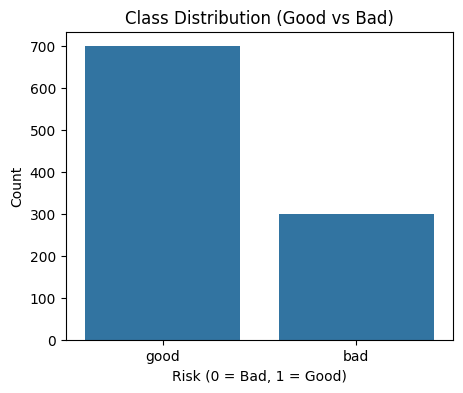

In [57]:
plt.figure(figsize=(5,4))
sns.countplot(x="Risk", data=df)
plt.title("Class Distribution (Good vs Bad)")
plt.xlabel("Risk (0 = Bad, 1 = Good)")
plt.ylabel("Count")
plt.show()

### Insight
The dataset is imbalanced, with more good customers(about 70%) than bad ones(about 30%). This can bias the model toward predicting the majority class.

### Credit Amount Vs Risk

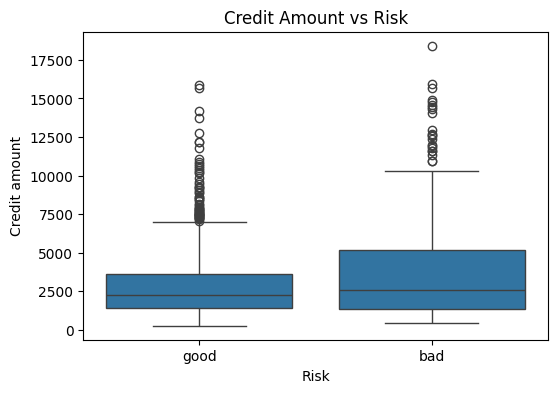

In [58]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Risk", y="Credit amount", data=df)
plt.title("Credit Amount vs Risk")
plt.show()

### Insight
Customers with higher credit amounts tend to have higher risk, indicating that loan size plays a role in default probability.

### Duration vs Risk

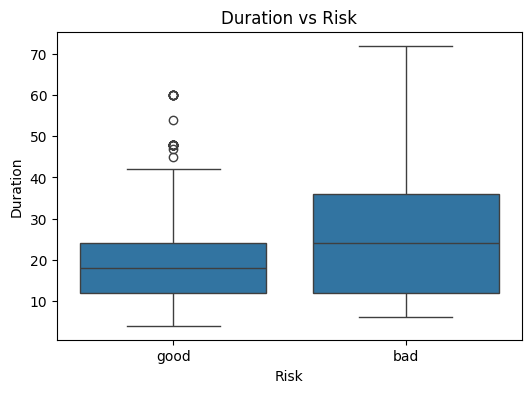

In [59]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Risk", y="Duration", data=df)
plt.title("Duration vs Risk")
plt.show()

### Insight
Longer loan durations are associated with higher risk, suggesting repayment time impacts default likelihood.

### Saving Accounts vs Risk

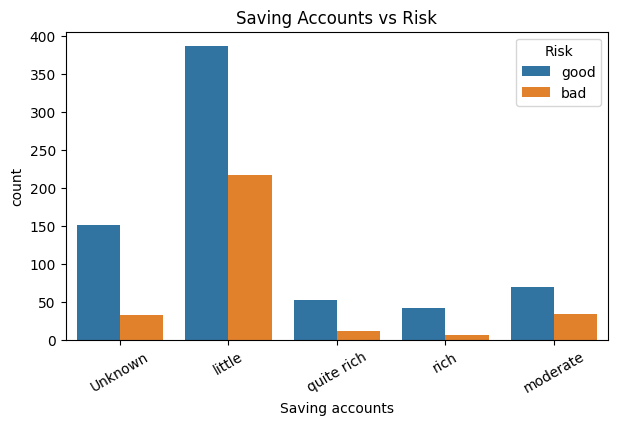

In [60]:
plt.figure(figsize=(7,4))
sns.countplot(x="Saving accounts", hue="Risk", data=df)
plt.title("Saving Accounts vs Risk")
plt.xticks(rotation=30)
plt.show()

### Insight
Customers with lower savings are more likely to be risky, showing financial stability is an important factor.

### Checking Amount vs Risk

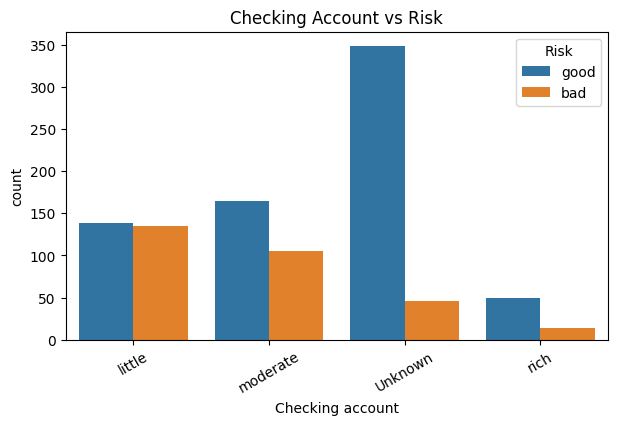

In [61]:
plt.figure(figsize=(7,4))
sns.countplot(x="Checking account", hue="Risk", data=df)
plt.title("Checking Account vs Risk")
plt.xticks(rotation=30)
plt.show()

### Insight

Customers with lower checking account balances are more likely to be risky, 
while customers with moderate to high balances are safer. 

This indicates that checking account balance is an important indicator of financial stability.

# Feature Engineering

In [62]:
# Feature Engineering
df["Credit_per_month"] = df["Credit amount"] / df["Duration"]

df["Saving_group"] = df["Saving accounts"].replace({
    "little": "low",
    "moderate": "medium",
    "rich": "high",
    "quite rich": "high",
    "Unknown": "unknown"
})

df["Checking_group"] = df["Checking account"].replace({
    "little": "low",
    "moderate": "medium",
    "rich": "high",
    "Unknown": "unknown"
})


df = df.drop(["Saving accounts", "Checking account"], axis=1)

In this step, new features were created to better represent the underlying financial behavior of customers and improve model performance.

### 1. Credit_per_month
A new feature **Credit_per_month** was created by dividing the total credit amount by the loan duration.

- This represents the **monthly financial burden** on the customer.
- A higher value indicates that the customer has to repay a larger amount in a shorter time, which may increase the risk of default.

---

### 2. Saving_group
The original *Saving accounts* feature had multiple categories. These were grouped into broader categories:

- **low** → little  
- **medium** → moderate  
- **high** → rich, quite rich  
- **unknown** → missing values  

This grouping helps:
- Reduce noise from too many categories  
- Capture overall financial strength more effectively  

---

### 3. Checking_group
Similarly, the *Checking account* feature was grouped into:

- **low** → little  
- **medium** → moderate  
- **high** → rich  
- **unknown** → missing values  

From EDA, it was observed that customers with lower checking balances tend to be more risky. Grouping simplifies this relationship and makes it easier for the model to learn.

---

### Summary
Feature engineering helped transform raw financial attributes into more meaningful representations, improving the model’s ability to detect risky customers.

In [63]:
df

,Age,Sex,Job,Housing,Credit amount,Duration,Purpose,Risk,Credit_per_month,Saving_group,Checking_group
0,67,male,2,own,1169,6,radio/TV,good,194.833333,unknown,low
1,22,female,2,own,5951,48,radio/TV,bad,123.979167,low,medium
2,49,male,1,own,2096,12,education,good,174.666667,low,unknown
3,45,male,2,free,7882,42,furniture/equipment,good,187.666667,low,low
4,53,male,2,free,4870,24,car,bad,202.916667,low,low
...,...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,1736,12,furniture/equipment,good,144.666667,low,unknown
996,40,male,3,own,3857,30,car,good,128.566667,low,low
997,38,male,2,own,804,12,radio/TV,good,67.000000,low,unknown
998,23,male,2,free,1845,45,radio/TV,bad,41.000000,low,low


# Data Preprocessing

In this step, the dataset is prepared for machine learning models by converting categorical variables into numerical form and splitting the data into training and testing sets.

### Train Test Split

In [64]:
#Separating features and target variable
X = df.drop("Risk", axis=1)
y = df["Risk"].map({"good": 1, "bad": 0})

In [65]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Encoding(One Hot Encoding)

In [ ]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns

In [71]:
Encoder = OneHotEncoder()
X_train_encoded = Encoder.fit_transform(X_train[[col for col in cat_cols if col in X_train.columns]])
X_test_encoded = Encoder.transform(X_test[[col for col in cat_cols if col in X_test.columns]])

X_train_encoded_df = pd.DataFrame(X_train_encoded.toarray(), columns= Encoder.get_feature_names_out(), index = X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded.toarray(), columns= Encoder.get_feature_names_out() , index = X_test.index)

X_train_final = pd.concat([X_train.drop(columns=cat_cols, errors='ignore'), X_train_encoded_df], axis=1)
X_test_final = pd.concat([X_test.drop(columns=cat_cols, errors='ignore'), X_test_encoded_df], axis=1)

X_train_final

,Age,Job,Credit amount,Duration,Credit_per_month,Sex_female,Sex_male,Housing_free,Housing_own,Housing_rent,...,Purpose_repairs,Purpose_vacation/others,Saving_group_high,Saving_group_low,Saving_group_medium,Saving_group_unknown,Checking_group_high,Checking_group_low,Checking_group_medium,Checking_group_unknown
29,63,2,6836,60,113.933333,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
535,33,2,2319,21,110.428571,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
695,50,2,1236,6,206.000000,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
557,29,2,5003,21,238.238095,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
836,21,2,886,12,73.833333,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,39,3,6458,18,358.777778,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
270,32,2,2662,18,147.888889,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
860,27,2,5804,24,241.833333,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
435,25,2,1484,12,123.666667,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0



Categorical variables such as *Sex, Housing, Purpose, Saving_group,* and *Checking_group* were converted into numerical format using one-hot encoding.

This transformation creates binary columns (0/1) for each category, allowing machine learning models to process categorical data effectively.


# Model Training 

### Model Selection

Multiple models were experimented with during the development phase, including Logistic Regression, Random Forest, and XGBoost.

Logistic Regression was selected as the final model due to its balanced performance, simplicity, and interpretability.

It also performed well after handling class imbalance, making it suitable for this problem.

In [72]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_final, y_train)
y_pred = model.predict(X_test_final)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.42      0.50        59
           1       0.79      0.89      0.83       141

    accuracy                           0.75       200
   macro avg       0.70      0.66      0.67       200
weighted avg       0.73      0.75      0.73       200



C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Model Performance

The model provides an initial understanding of how well the features can predict customer risk.

### Key Observations
- The model performs well in predicting the majority class (good customers)  
- However, the recall for the bad class (0) is relatively low  
- This indicates that the model struggles to correctly identify risky customers  

### Insight
Since the dataset is imbalanced, the model tends to favor the majority class.  
This highlights the need for techniques to handle class imbalance in the next step.

## Handling Class Imbalance

The dataset is imbalanced, with significantly more good customers than bad ones.

This can cause the model to be biased toward predicting the majority class.

To address this issue, SMOTE (Synthetic Minority Oversampling Technique) is applied to balance the training data.

In [ ]:
#Oversampling using SMOTE
oversampler = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train_final, y_train)

#model training after resampling
model.fit(X_train_resampled, y_train_resampled)
y_pred_resampled = model.predict(X_test_final)

#Evaluation after resampling
print(classification_report(y_test, y_pred_resampled))

              precision    recall  f1-score   support

           0       0.49      0.68      0.57        59
           1       0.84      0.71      0.77       141

    accuracy                           0.70       200
   macro avg       0.67      0.69      0.67       200
weighted avg       0.74      0.70      0.71       200



C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Model Performance After SMOTE

After applying SMOTE, the recall for the bad class improved significantly.

This indicates that the model is now better at identifying risky customers.

Although overall accuracy may decrease slightly, the model becomes more useful for real-world risk prediction.

### Key Insight
In credit risk problems, identifying bad customers is more important than overall accuracy.

# Confusion Matrix

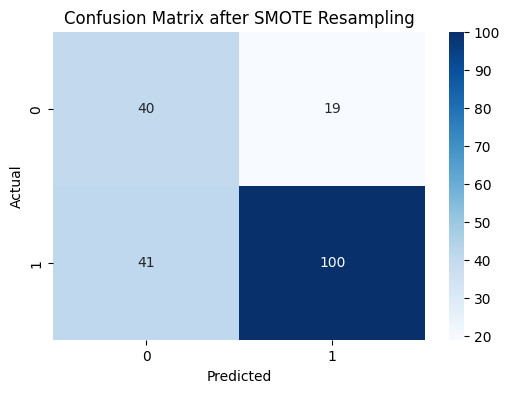

In [76]:
cof_matrix = confusion_matrix(y_test, y_pred_resampled)
plt.figure(figsize=(6,4))
sns.heatmap(cof_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix after SMOTE Resampling")    
plt.show()


### Confusion Matrix Interpretation

The confusion matrix shows how well the model distinguishes between good and bad customers.

After applying SMOTE, the model correctly identifies more bad customers compared to the baseline model, indicating improved recall for the minority class.

## Model Comparison

| Metric | Before SMOTE | After SMOTE |
|-------|-------------|-------------|
| Recall (Bad Class) | 0.42 | 0.68 |
| Accuracy | 0.75 | 0.70 |

### Insight
- Recall improved after handling class imbalance  
- Accuracy may decrease slightly  
- Model becomes more reliable for detecting risky customers

# Final Conclusion

- Feature engineering improved representation of customer financial behavior  
- One-hot encoding enabled proper handling of categorical variables  
- Logistic Regression provided a strong baseline model  
- Applying SMOTE significantly improved the model's ability to detect risky customers  

### Key Insight
In credit risk prediction, identifying bad customers is more important than achieving high accuracy, as misclassification can lead to financial loss.

### Final Outcome
The model is now better suited for real-world risk assessment tasks.

# Future Work

- Collect more data for better generalization  
- Use advanced models such as XGBoost  
- Perform hyperparameter tuning  
- Explore additional financial features  